# Frenet Frames

a.k.a. Frenet--Serret, a.k.a. TNB frame

[Jean Frédéric Frenet](https://en.wikipedia.org/wiki/Jean_Frédéric_Frenet),
[Joseph Alfred Serret](https://en.wikipedia.org/wiki/Joseph_Alfred_Serret)

tangent, normal, binormal, curvature, torsion, twist, ...

TODO: osculating circle (separate notebook)?

TODO: 2D example with simple normal vector

TODO: 3D example with 3D object

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import splines

In [3]:
def plot_spline(spline, dots_per_second=15, ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()
    total_duration = spline.grid[-1] - spline.grid[0]
    times = spline.grid[0] + np.arange(int(total_duration * dots_per_second) + 1) / dots_per_second
    ax.plot(*spline.evaluate(spline.grid).T,
            linestyle=':', color='lightgrey',
            marker='x', markeredgecolor='black')
    ax.plot(*spline.evaluate(times).T, '.', **kwargs)
    
    from matplotlib.collections import LineCollection
    positions = s.evaluate(times)
    accelerations = s.evaluate(times, 2)
    # TODO: normalize vectors?
    lines = zip(positions, positions + accelerations * 0.1)
    lc = LineCollection(lines, colors='red')
    ax.add_collection(lc)
    #ax.autoscale()
    #ax.margins(0.1)
    ax.axis('equal');

In [4]:
vertices = [
    (0, 0),
    (1, 1),
    (2, 0),
    (3, 1),
]

In [5]:
s = splines.CatmullRom(vertices)

In [6]:
times = 0, 0.5, 1

In [7]:
s.tangent(times)

array([[0.5547002 , 0.83205029],
       [0.66436384, 0.74740932],
       [1.        , 0.        ]])

In [8]:
s.tangent(0)

IndexError: invalid index to scalar variable.

In [7]:
s.evaluate(0, 1)

array([1. , 1.5])

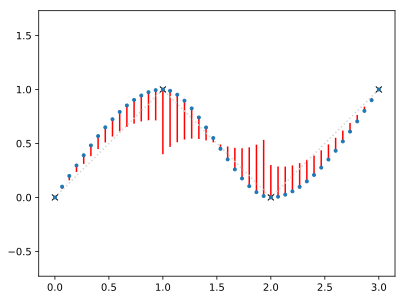

In [9]:
plot_spline(s)

In [10]:
vertices = [
    (0, 0.5),
    (1.5, 0.75),
    (2, 0.5),
    (2.5, 0.25),
    (3, 0),
    (4, 0.25),
]

In [11]:
s = splines.CatmullRom(vertices, alpha=0.5)

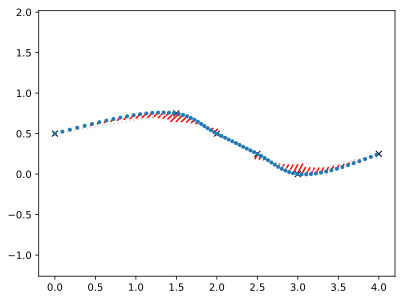

In [128]:
plot_spline(s)